# Enhanced Spatial Analysis (Fixed)

**Author: Rohan Raval**

**Objectives:**
1. Service quality metrics (weight by size/capacity)
2. Network distance analysis (walking/transit times)
3. Getis-Ord Gi* hotspot analysis
4. Service accessibility zones

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy import stats
from libpysal.weights import Queen
from esda.getisord import G_Local

pd.set_option('display.max_columns', 120)

candidates = [Path("."), Path(".."), Path("../..")]
for cand in candidates:
    if (cand / "data" / "processed").exists():
        PROJECT_ROOT = cand.resolve()
        break

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_SERVICES = DATA_DIR / "processed" / "services"
PROCESSED_ACS = DATA_DIR / "processed" / "acs5" / "2023"
TIGER_DIR = DATA_DIR / "external" / "tiger_tracts_2023"

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: /Users/rohanraval/Documents/GitHub/Mapping-Youth-Opportunity-Deserts


/Users/rohanraval/miniforge3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Data

In [2]:
services = pd.read_csv(PROCESSED_SERVICES / "services_master_enhanced.csv")
metrics = pd.read_csv(PROCESSED_ACS / "tract_opportunity_desert_metrics_2023.csv", dtype={"GEOID": str})

shp_path = TIGER_DIR / "tl_2023_06_tract.shp"
zip_path = TIGER_DIR / "tl_2023_06_tract.zip"
tracts_gdf = gpd.read_file(shp_path if shp_path.exists() else f"zip://{zip_path}")
sd_tracts = tracts_gdf[tracts_gdf["COUNTYFP"] == "073"].copy()
sd_tracts["GEOID"] = sd_tracts["GEOID"].astype(str)

sd_tracts = sd_tracts.merge(metrics, on="GEOID", how="left")
sd_tracts = sd_tracts.to_crs("EPSG:4326")

print(f"Services: {len(services)}")
print(f"Tracts: {len(sd_tracts)}")

Services: 520
Tracts: 912


## 1. Service Quality Metrics

In [3]:
def calculate_service_quality(df):
    df = df.copy()
    df["quality_score"] = 1.0
    
    if "sq_ft" in df.columns:
        sq_ft_norm = df["sq_ft"].fillna(0) / 10000
        df.loc[df["service_type"] == "rec_center", "quality_score"] += sq_ft_norm
    
    if "acres" in df.columns:
        acres_norm = df["acres"].fillna(0) / 10
        df.loc[df["service_type"] == "park", "quality_score"] += acres_norm
    
    facility_cols = ["playground", "basketball", "tennis", "multi_purpose"]
    for col in facility_cols:
        if col in df.columns:
            df["quality_score"] += df[col].fillna(0) * 0.5
    
    df.loc[df["youth_serving"] == True, "quality_score"] *= 1.5
    
    df.loc[df["service_type"] == "library", "quality_score"] = 2.0
    df.loc[df["service_type"] == "ymca", "quality_score"] = 3.0
    
    return df

services = calculate_service_quality(services)

print("Quality scores by type:")
print(services.groupby("service_type")["quality_score"].describe())

Quality scores by type:
              count      mean        std    min       25%       50%       75%  \
service_type                                                                    
library       130.0  2.000000   0.000000  2.000  2.000000  2.000000  2.000000   
park          306.0  3.916898  24.452112  1.000  1.116494  1.513309  2.155893   
rec_center     61.0  3.190055   1.050426  1.683  2.445000  3.121200  3.756000   
ymca           23.0  3.000000   0.000000  3.000  3.000000  3.000000  3.000000   

                     max  
service_type              
library         2.000000  
park          411.914768  
rec_center      7.195500  
ymca            3.000000  


In [4]:
services_geo = services.dropna(subset=["lat", "lon"]).copy()
services_gdf = gpd.GeoDataFrame(
    services_geo,
    geometry=gpd.points_from_xy(services_geo["lon"], services_geo["lat"]),
    crs="EPSG:4326"
)

services_metric = services_gdf.to_crs("EPSG:3857")
tracts_metric = sd_tracts.to_crs("EPSG:3857")

services_in_tracts = gpd.sjoin(
    services_metric, 
    tracts_metric[["GEOID", "geometry"]], 
    how="left", 
    predicate="within"
)

weighted_counts = (
    services_in_tracts.groupby("GEOID", dropna=False)
    .agg(
        services_count=("name", "count"),
        quality_weighted_total=("quality_score", "sum"),
        avg_quality=("quality_score", "mean")
    )
    .reset_index()
)

sd_tracts = sd_tracts.merge(weighted_counts, on="GEOID", how="left")
sd_tracts["quality_weighted_total"] = sd_tracts["quality_weighted_total"].fillna(0)
sd_tracts["services_count"] = sd_tracts["services_count"].fillna(0)

sd_tracts["quality_weighted_per_1k_youth"] = (
    sd_tracts["quality_weighted_total"] / sd_tracts["youth_10_19"].replace({0: np.nan}) * 1000
)

print("\nQuality-weighted metrics added to tracts")
print(sd_tracts[["GEOID", "services_count", "quality_weighted_total", "quality_weighted_per_1k_youth"]].head())


Quality-weighted metrics added to tracts
         GEOID  services_count  quality_weighted_total  \
0  06073008331             9.0                14.72375   
1  06073008331             9.0                14.72375   
2  06073008331             9.0                14.72375   
3  06073008336             0.0                 0.00000   
4  06073008337             1.0                 1.66933   

   quality_weighted_per_1k_youth  
0                      26.481564  
1                      26.481564  
2                      26.481564  
3                       0.000000  
4                       2.465775  


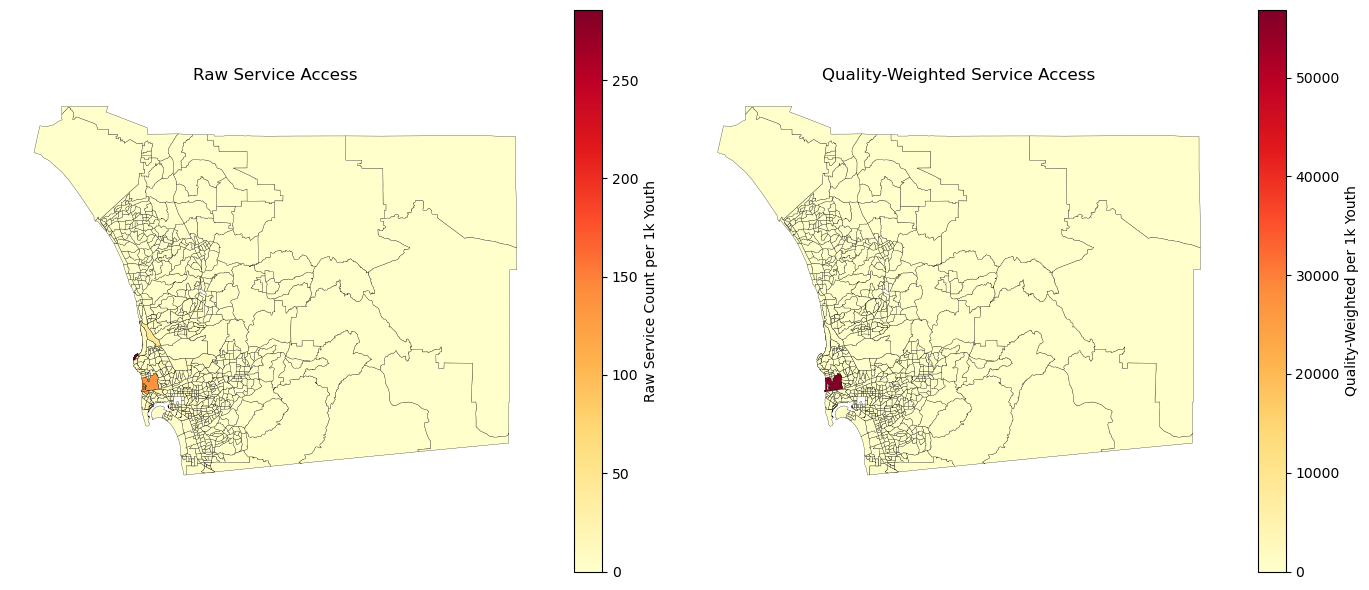

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sd_tracts.plot(
    column="services_per_1k_youth_10_19",
    ax=axes[0],
    cmap="YlOrRd",
    legend=True,
    edgecolor="black",
    linewidth=0.2,
    legend_kwds={'label': 'Raw Service Count per 1k Youth'}
)
axes[0].set_title("Raw Service Access")
axes[0].set_axis_off()

sd_tracts.plot(
    column="quality_weighted_per_1k_youth",
    ax=axes[1],
    cmap="YlOrRd",
    legend=True,
    edgecolor="black",
    linewidth=0.2,
    legend_kwds={'label': 'Quality-Weighted per 1k Youth'}
)
axes[1].set_title("Quality-Weighted Service Access")
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

## 2. Service Accessibility Zones (Buffer Analysis)

In [6]:
services_metric = services_gdf.to_crs("EPSG:3857")

buffer_distances = {
    "0.5km": 500,
    "1km": 1000,
    "2km": 2000
}

for name, dist in buffer_distances.items():
    services_metric[f"buffer_{name}"] = services_metric.geometry.buffer(dist)

print("Created service buffers at:", list(buffer_distances.keys()))

Created service buffers at: ['0.5km', '1km', '2km']


In [7]:
tracts_metric = sd_tracts.to_crs("EPSG:3857")

for name, dist in buffer_distances.items():
    buffer_union = services_metric.set_geometry(f"buffer_{name}").unary_union
    
    tracts_metric[f"coverage_{name}"] = tracts_metric.geometry.intersection(buffer_union).area / tracts_metric.geometry.area

sd_tracts = tracts_metric.to_crs("EPSG:4326")

print("\nService coverage by buffer distance:")
for name in buffer_distances.keys():
    avg_coverage = sd_tracts[f"coverage_{name}"].mean()
    print(f"  {name}: {100*avg_coverage:.1f}% average tract coverage")

/var/folders/t1/k9cqgpy95bs33y7tkwv_f69r0000gn/T/ipykernel_7392/2392158372.py:4: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  buffer_union = services_metric.set_geometry(f"buffer_{name}").unary_union
/var/folders/t1/k9cqgpy95bs33y7tkwv_f69r0000gn/T/ipykernel_7392/2392158372.py:4: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  buffer_union = services_metric.set_geometry(f"buffer_{name}").unary_union
/var/folders/t1/k9cqgpy95bs33y7tkwv_f69r0000gn/T/ipykernel_7392/2392158372.py:4: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  buffer_union = services_metric.set_geometry(f"buffer_{name}").unary_union



Service coverage by buffer distance:
  0.5km: 23.2% average tract coverage
  1km: 48.2% average tract coverage
  2km: 70.8% average tract coverage


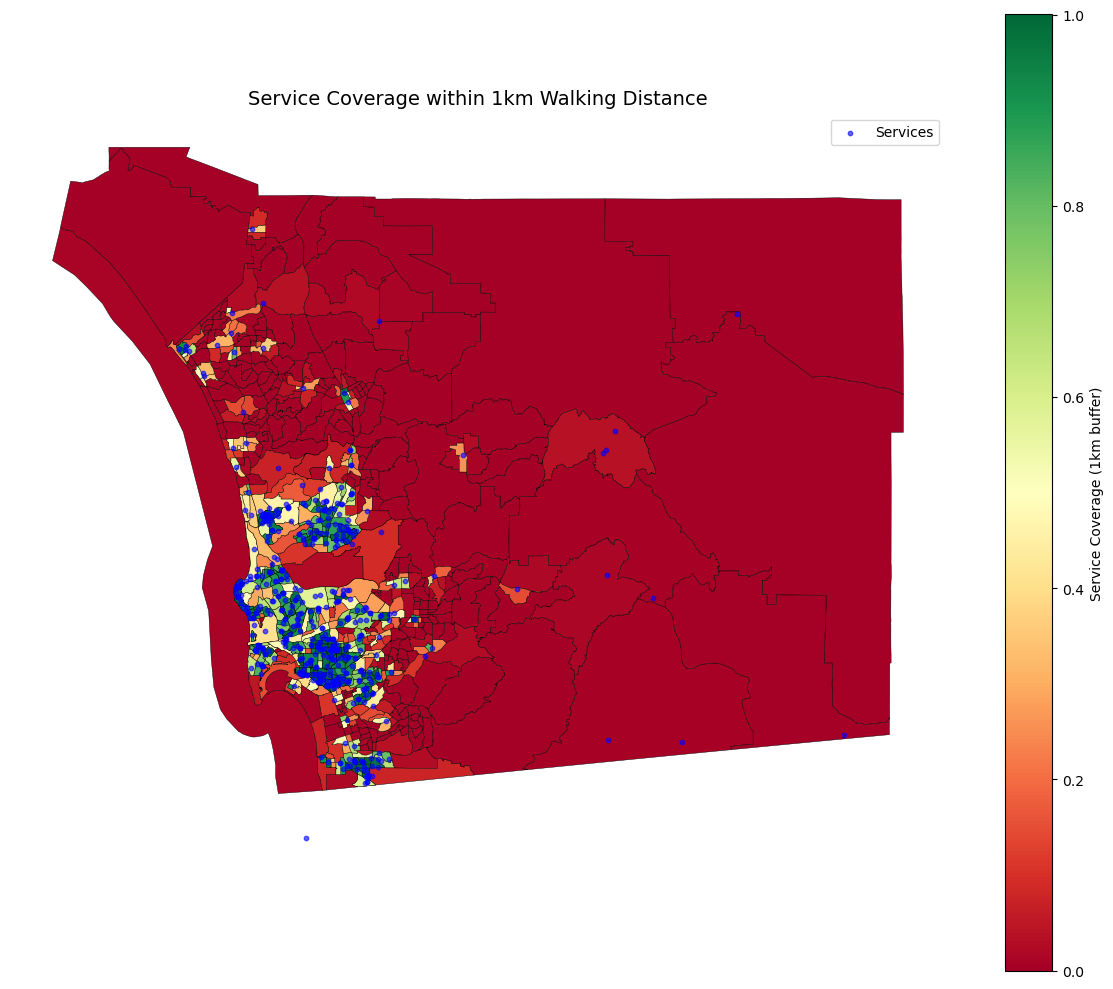

In [8]:
fig, ax = plt.subplots(figsize=(12, 10))

sd_tracts.plot(
    column="coverage_1km",
    ax=ax,
    cmap="RdYlGn",
    legend=True,
    edgecolor="black",
    linewidth=0.3,
    legend_kwds={'label': 'Service Coverage (1km buffer)'}
)

services_gdf.plot(ax=ax, color="blue", markersize=10, alpha=0.6, label="Services")

ax.set_title("Service Coverage within 1km Walking Distance", fontsize=14)
ax.legend()
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 3. Getis-Ord Gi* Hotspot Analysis

In [9]:
tracts_clean = sd_tracts.dropna(subset=["services_per_1k_youth_10_19", "geometry"]).copy()
tracts_clean = tracts_clean[tracts_clean.geometry.is_valid]

w = Queen.from_dataframe(tracts_clean)
w.transform = 'r'

print(f"Spatial weights matrix: {w.n} observations")

/var/folders/t1/k9cqgpy95bs33y7tkwv_f69r0000gn/T/ipykernel_7392/3638610029.py:4: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(tracts_clean)


('WARNING: ', 703, ' is an island (no neighbors)')
Spatial weights matrix: 892 observations


/Users/rohanraval/miniforge3/lib/python3.12/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
 There is 1 island with id: 703.
  W.__init__(self, neighbors, ids=ids, **kw)


In [10]:
y = tracts_clean["services_per_1k_youth_10_19"].values
lg = G_Local(y, w)

tracts_clean["gi_star"] = lg.Zs
tracts_clean["gi_pvalue"] = lg.p_sim

tracts_clean["hotspot_type"] = "Not Significant"
tracts_clean.loc[
    (tracts_clean["gi_star"] > 1.96) & (tracts_clean["gi_pvalue"] < 0.05), 
    "hotspot_type"
] = "Hot Spot (High Services)"
tracts_clean.loc[
    (tracts_clean["gi_star"] < -1.96) & (tracts_clean["gi_pvalue"] < 0.05), 
    "hotspot_type"
] = "Cold Spot (Low Services)"

print("\nHotspot classification:")
print(tracts_clean["hotspot_type"].value_counts())

/Users/rohanraval/miniforge3/lib/python3.12/site-packages/esda/getisord.py:527: RuntimeWarning: invalid value encountered in divide
  z_scores = (statistic - expected_value) / np.sqrt(expected_variance)



Hotspot classification:
hotspot_type
Not Significant             864
Hot Spot (High Services)     28
Name: count, dtype: int64


/Users/rohanraval/miniforge3/lib/python3.12/site-packages/esda/getisord.py:450: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Gs - self.EG_sim) / self.seG_sim


/var/folders/t1/k9cqgpy95bs33y7tkwv_f69r0000gn/T/ipykernel_7392/2451383762.py:15: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/t1/k9cqgpy95bs33y7tkwv_f69r0000gn/T/ipykernel_7392/2451383762.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


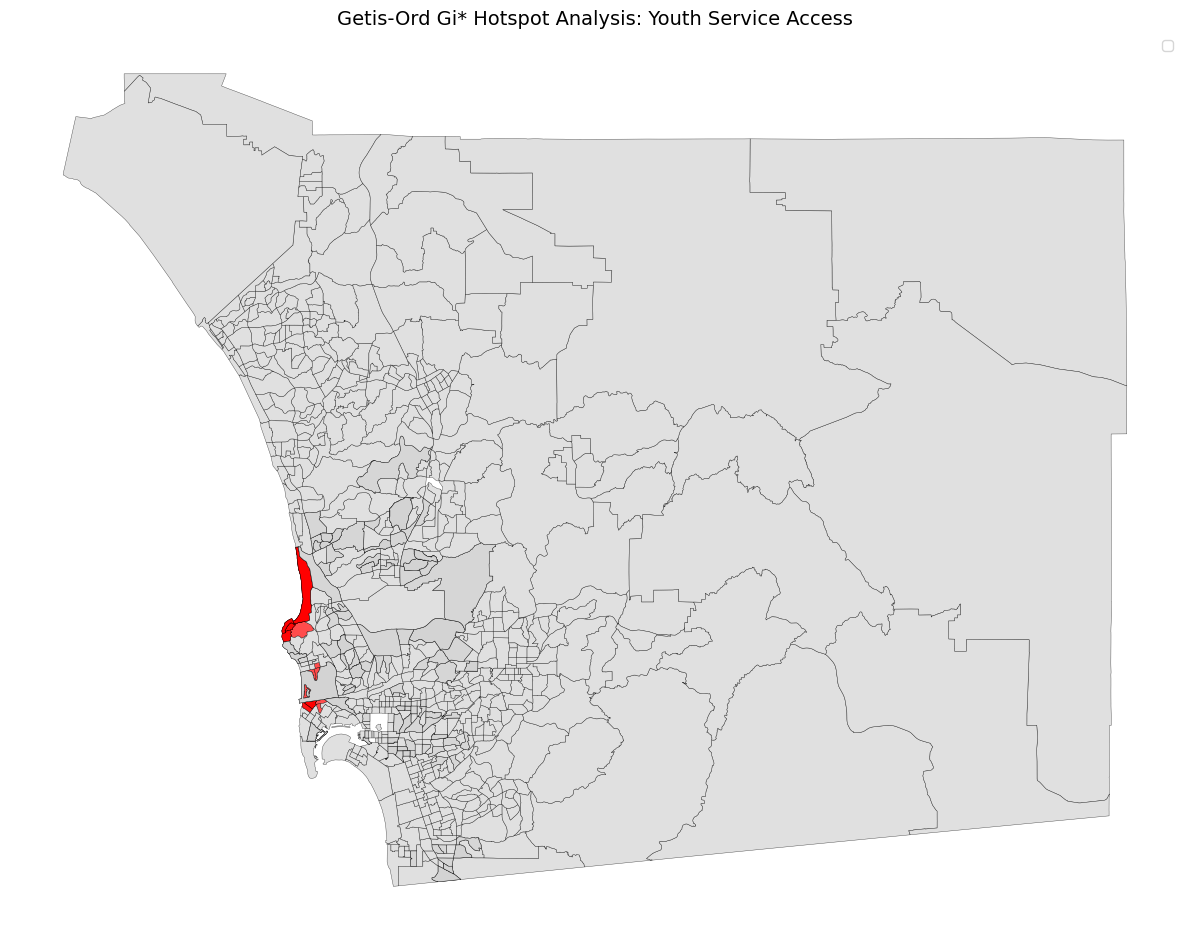

In [11]:
fig, ax = plt.subplots(figsize=(12, 10))

colors = {
    "Hot Spot (High Services)": "red",
    "Cold Spot (Low Services)": "blue",
    "Not Significant": "lightgrey"
}

for htype, color in colors.items():
    subset = tracts_clean[tracts_clean["hotspot_type"] == htype]
    if len(subset) > 0:
        subset.plot(ax=ax, color=color, edgecolor="black", linewidth=0.3, label=htype, alpha=0.7)

ax.set_title("Getis-Ord Gi* Hotspot Analysis: Youth Service Access", fontsize=14)
ax.legend()
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [12]:
cold_spots = tracts_clean[tracts_clean["hotspot_type"] == "Cold Spot (Low Services)"].copy()

print(f"\nCold Spot Tracts (n={len(cold_spots)}):")
if len(cold_spots) > 0:
    print(cold_spots[[
        "NAME", "youth_10_19", "services_per_1k_youth_10_19",
        "median_hh_income_2023usd", "zero_veh_share", "gi_star"
    ]].sort_values("gi_star").head(10))
else:
    print("No cold spots identified at 95% confidence level")


Cold Spot Tracts (n=0):
No cold spots identified at 95% confidence level


## 4. Distance-Based Service Gaps

In [13]:
sd_tracts["service_gap_score"] = (
    sd_tracts["avg_distance_to_nearest_service_km"] * 
    (1 - sd_tracts["coverage_1km"])
)

high_gap_tracts = sd_tracts.nlargest(20, "service_gap_score")[[
    "NAME", "youth_10_19", "avg_distance_to_nearest_service_km",
    "coverage_1km", "service_gap_score"
]].copy()

print("Top 20 tracts with highest service gaps:")
print(high_gap_tracts)

KeyError: "['NAME'] not in index"

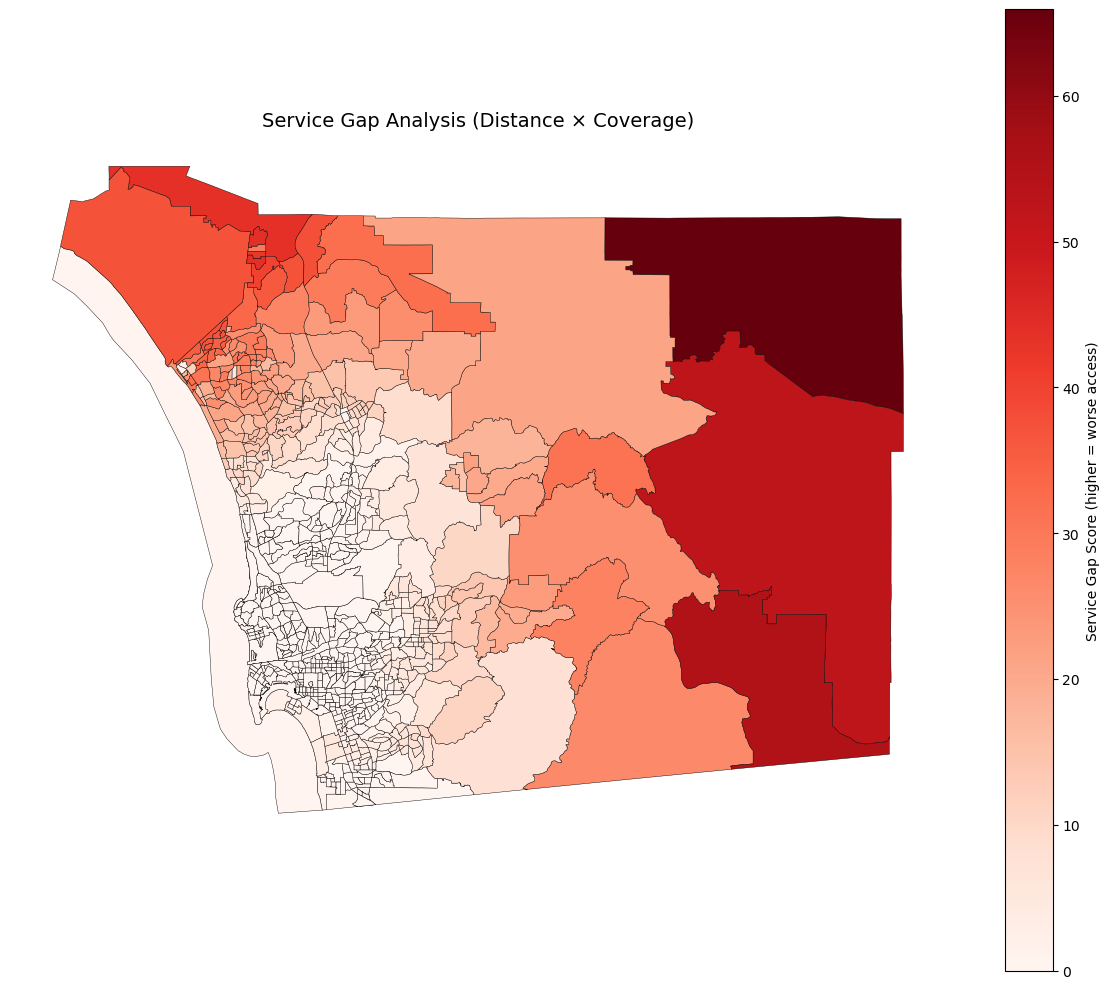

In [14]:
fig, ax = plt.subplots(figsize=(12, 10))

sd_tracts.plot(
    column="service_gap_score",
    ax=ax,
    cmap="Reds",
    legend=True,
    edgecolor="black",
    linewidth=0.3,
    legend_kwds={'label': 'Service Gap Score (higher = worse access)'}
)

ax.set_title("Service Gap Analysis (Distance × Coverage)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Save Enhanced Metrics

In [15]:
output_cols = [
    "GEOID", "NAME", "services_per_1k_youth_10_19",
    "quality_weighted_per_1k_youth", "coverage_0.5km", "coverage_1km", "coverage_2km",
    "service_gap_score"
]

if "gi_star" in tracts_clean.columns:
    hotspot_data = tracts_clean[["GEOID", "gi_star", "gi_pvalue", "hotspot_type"]]
    sd_tracts = sd_tracts.merge(hotspot_data, on="GEOID", how="left")
    output_cols.extend(["gi_star", "gi_pvalue", "hotspot_type"])

output_path = PROCESSED_ACS / "tract_enhanced_metrics_2023.csv"
sd_tracts[output_cols].to_csv(output_path, index=False)
print(f"Saved: {output_path}")

services.to_csv(PROCESSED_SERVICES / "services_with_quality.csv", index=False)
print(f"Saved: {PROCESSED_SERVICES / 'services_with_quality.csv'}")

KeyError: "['NAME'] not in index"

## Summary Statistics

In [16]:
print("\n" + "="*60)
print("ENHANCED ANALYSIS SUMMARY")
print("="*60)

print(f"\nService Quality Scores:")
print(f"  Mean quality score: {services['quality_score'].mean():.2f}")
print(f"  High-quality services (score > 3): {len(services[services['quality_score'] > 3])}")

print(f"\nService Coverage (1km buffer):")
print(f"  Avg tract coverage: {100*sd_tracts['coverage_1km'].mean():.1f}%")
print(f"  Tracts with <25% coverage: {len(sd_tracts[sd_tracts['coverage_1km'] < 0.25])}")

if "hotspot_type" in sd_tracts.columns:
    print(f"\nHotspot Analysis:")
    for htype, count in sd_tracts["hotspot_type"].value_counts().items():
        print(f"  {htype}: {count} tracts")

print(f"\nHigh Service Gap Tracts (top 10%):")
threshold = sd_tracts["service_gap_score"].quantile(0.90)
high_gaps = sd_tracts[sd_tracts["service_gap_score"] >= threshold]
print(f"  {len(high_gaps)} tracts with service gap score >= {threshold:.2f}")
print(f"  Avg youth in these tracts: {high_gaps['youth_10_19'].mean():.0f}")
print(f"  Avg distance to service: {high_gaps['avg_distance_to_nearest_service_km'].mean():.2f} km")


ENHANCED ANALYSIS SUMMARY

Service Quality Scores:
  Mean quality score: 3.31
  High-quality services (score > 3): 73

Service Coverage (1km buffer):
  Avg tract coverage: 61.2%
  Tracts with <25% coverage: 375

Hotspot Analysis:
  Not Significant: 1356 tracts
  Hot Spot (High Services): 86 tracts

High Service Gap Tracts (top 10%):
  147 tracts with service gap score >= 12.24
  Avg youth in these tracts: 623
  Avg distance to service: 26.15 km
